#### Question 7: DDIM sampling on trained DDPM

Observation: Sampling using DDIM was faster than using DDPM. \
FID is not coming good because of incomplete training of DDPM model.


In [1]:
model_name = "ddim"
import os
import math
import torch
import numpy as np
import torch.nn as nn
import torchvision
from PIL import Image
import matplotlib.pyplot as plt
import torch.nn.functional as F

from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision.utils import make_grid, save_image
from torchvision.datasets import ImageFolder

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
path = os.path.join(os.getcwd(), "data", "butterfly")
image_size = 128
workers = 8
mean = torch.tensor([0.47998455, 0.46537864, 0.33653912])
std = torch.tensor([0.22608626, 0.22103393, 0.21348171])
transform = transforms.Compose(
    [
        transforms.Resize(image_size),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ]
)
data = ImageFolder(path, transform=transform)
img_size = 128
batch_size = 128
dataloader = DataLoader(data, batch_size=batch_size, shuffle=True, drop_last=True)


#### Building the Diffusion Model


In [4]:
def schedule_beta(num_steps, beta_start=0.0001, beta_end=0.02):
    return torch.linspace(beta_start, beta_end, num_steps).to(device)


# Define beta schedule
T = 1000  # Number of steps for Markov chain
betas = schedule_beta(num_steps=T)

# Pre-calculate various terms for closed form solution
alphas = 1.0 - betas
alpha_bar = torch.cumprod(alphas, dim=0) + 1e-8


def sample_forward_diffusion(x_initial, t):
    noise = torch.randn_like(x_initial).to(device)
    alpha_bar_t = alpha_bar[t].to(device).view(-1, 1, 1, 1)  # Reshape for broadcasting
    return alpha_bar_t.sqrt() * x_initial + (1 - alpha_bar_t).sqrt() * noise, noise

##### UNet Architecture


In [ ]:
class Block(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim, up=False):
        super().__init__()
        self.time_mlp = nn.Linear(time_emb_dim, out_ch)
        if up:
            self.conv1 = nn.Conv2d(2 * in_ch, out_ch, 3, padding=1)
            self.transform = nn.ConvTranspose2d(out_ch, out_ch, 4, 2, 1)
        else:
            self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
            self.transform = nn.Conv2d(out_ch, out_ch, 4, 2, 1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.bnorm1 = nn.BatchNorm2d(out_ch)
        self.bnorm2 = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU()

    def forward(
        self,
        x,
        t,
    ):
        # First Conv
        h = self.bnorm1(self.relu(self.conv1(x)))
        # Time embedding
        time_emb = self.relu(self.time_mlp(t))
        # Extend last 2 dimensions
        time_emb = time_emb[(...,) + (None,) * 2]
        # Add time channel
        h = h + time_emb
        # Second Conv
        h = self.bnorm2(self.relu(self.conv2(h)))
        # Down or Upsample
        return self.transform(h)


class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        # TODO: Double check the ordering here
        return embeddings


class SimpleUnet(nn.Module):
    """
    A simplified variant of the Unet architecture.
    """

    def __init__(self):
        super().__init__()
        image_channels = 3
        down_channels = (64, 128, 256, 512)
        up_channels = (512, 256, 128, 64)
        out_dim = 3
        time_emb_dim = 256

        # Time embedding
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.ReLU(),
        )
        # Initial projection
        self.conv0 = nn.Conv2d(image_channels, down_channels[0], 3, padding=1)

        # Downsample
        self.downs = nn.ModuleList(
            [
                Block(down_channels[i], down_channels[i + 1], time_emb_dim)
                for i in range(len(down_channels) - 1)
            ]
        )
        # Upsample
        self.ups = nn.ModuleList(
            [
                Block(up_channels[i], up_channels[i + 1], time_emb_dim, up=True)
                for i in range(len(up_channels) - 1)
            ]
        )
        # Edit: Corrected a bug found by Jakub C (see YouTube comment)
        self.output = nn.Conv2d(up_channels[-1], out_dim, 1)

    def forward(self, x, t):
        # Embedd time
        t = self.time_mlp(t)
        # Initial conv
        x = self.conv0(x)
        # Unet
        residual_inputs = []
        for down in self.downs:
            x = down(x, t)
            residual_inputs.append(x)
        for up in self.ups:
            residual_x = residual_inputs.pop()
            # Add residual x as additional channels
            x = torch.cat((x, residual_x), dim=1)
            x = up(x, t)
        return self.output(x)


model = SimpleUnet().to(device)
print("Num params: ", sum(p.numel() for p in model.parameters()))


# initialize all the parameters
def weights_init(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
        nn.init.kaiming_normal_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.ones_(m.weight)
        nn.init.zeros_(m.bias)
    elif isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight)
        nn.init.zeros_(m.bias)


model.load_state_dict(torch.load("trained_new.pth"))

In [ ]:
class DDIM:
    def __init__(self, model, device, model_n_steps, ddim_n_step, beta, ddim_sigms_eta = 0.0):
        self.device = device
        self.model=model

        self.model_n_steps = model_n_steps
        self.ddim_n_step = ddim_n_step

        self.time_steps = torch.arange(0,model_n_steps, model_n_steps//ddim_n_step).int() + 1
        
        #remove 1000 from the time steps if it is there
        self.time_steps = self.time_steps[self.time_steps!=model_n_steps]
        self.time_steps = self.time_steps.to(self.device)
        
        
        self.beta = beta.to(self.device)
        self.alpha = 1. - self.beta
        alpha_hat = self.alpha.cumprod(dim=0)
        self.alpha_hat = alpha_hat.to(self.device)
        assert (self.time_steps[:-1] < alpha_hat.size(0)).all(), "Index out of bounds"
        # Get alpha_bar for time steps of ddim
        self.ddim_alpha_hat = alpha_hat[self.time_steps].clone().detach().to(torch.float32).to(self.device)
        # Sqrt of alpha_hat_t for t in time steps
        self.sqrt_ddim_alpha_hat = torch.sqrt(self.ddim_alpha_hat).to(self.device)
        # Alpha_hat_t-1 for t in time steps
        self.ddim_alpha_hat_prev = torch.cat([alpha_hat[0:1], alpha_hat[self.time_steps[:-1]]]).to(self.device)
        # Sqrt of 1-alpha_hat_t for t in time steps
        self.ddim_sqrt_one_minus_alpha_hat = torch.sqrt(1. - self.ddim_alpha_hat).to(self.device)
        # DDIM sigma for t in time steps
        self.ddim_sigmas = ddim_sigms_eta * torch.sqrt((1. - self.ddim_alpha_hat_prev) / (1. - self.ddim_alpha_hat) * (1 - self.ddim_alpha_hat / self.ddim_alpha_hat_prev)).to(self.device)
    @torch.no_grad()
    def q_sample(self, x0, index, noise=None):
        if noise is None:
            noise = torch.randn_like(x0).to(self.device)

        return self.sqrt_ddim_alpha_hat[index] * x0 + self.ddim_sqrt_one_minus_alpha_hat[index] * noise
    def get_eps(self, x,t):
        return self.model(x, t)
    @torch.no_grad()
    def sampler(self, num_samples=None, x_last=None):
        if x_last is None:
            x_last = torch.randn(num_samples, 3, 128, 128, device=self.device)
        x = x_last.to(self.device)
        time_steps= torch.flip(self.time_steps, [0])
        for i, step in enumerate(time_steps):
            index = len(time_steps) - i - 1
            ts=x.new_full((x.size(0),), step, dtype=torch.long).to(self.device)
            #ts is time step for x_t

            x, predicted_x0, e_t= self.p_sample(x, ts, index=index)
            
        #normalize the image

        x = (x - x.min())/(x.max() - x.min()+1e-6)
            
        
        return x
    
    @torch.no_grad()
    def p_sample(self, x, t, index):

        eps_t = self.get_eps(x, t)

        alpha_hat = self.ddim_alpha_hat[index]

        alpha_hat_prev = self.ddim_alpha_hat_prev[index]    

        sigma = self.ddim_sigmas[index]

        sqrt_one_minus_alpha_hat = self.ddim_sqrt_one_minus_alpha_hat[index]

        noise = torch.randn_like(x, device=self.device)

        predicted_x0 = (x-sqrt_one_minus_alpha_hat*eps_t)/(alpha_hat ** 0.5)

        x_previous = alpha_hat_prev ** 0.5 * predicted_x0 + (1. - alpha_hat_prev -sigma**2).sqrt() * eps_t + sigma * noise

        return x_previous, predicted_x0, eps_t
# Initialize DDIM
ddim = DDIM(model, device, model_n_steps=T, ddim_n_step=50, beta=betas)


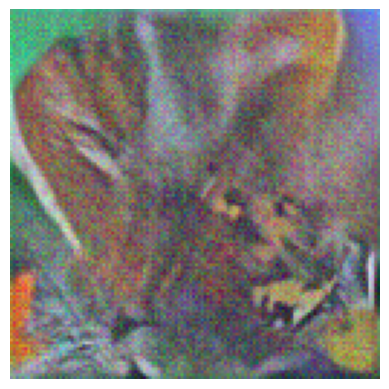

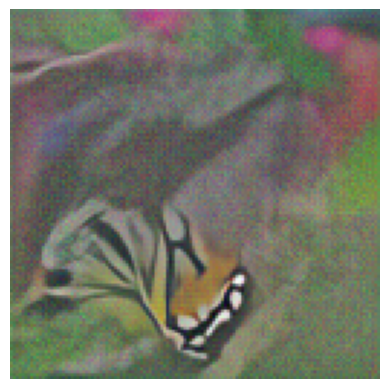

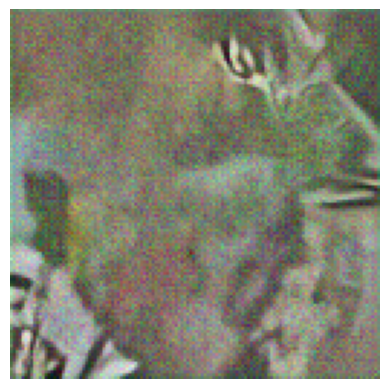

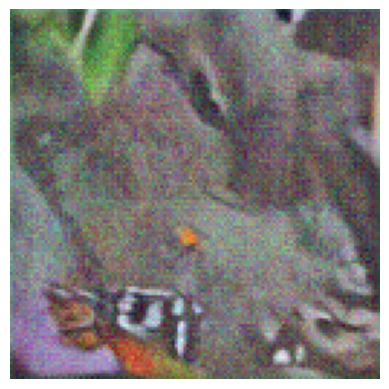

In [ ]:

# Sample from DDIM
x = ddim.sampler(num_samples=4)
plt.imshow(x[0].permute(1, 2, 0).cpu().numpy())
plt.axis('off')
plt.show()
plt.imshow(x[1].permute(1, 2, 0).cpu().numpy())
plt.axis('off')
plt.show()
plt.imshow(x[2].permute(1, 2, 0).cpu().numpy())
plt.axis('off')
plt.show()
plt.imshow(x[3].permute(1, 2, 0).cpu().numpy())
plt.axis('off')
plt.show()


#### FID calculation for DDIM Generation Quality

In [ ]:
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
import random
from torcheval.metrics import FrechetInceptionDistance


# Load the model
model.eval()
torch.cuda.empty_cache()

# Number of images to generate
n_images = 1000
batch_size = 100  # Process images in smaller batches

# Create a DataLoader for the dataset
dataloader = DataLoader(data, batch_size=batch_size, shuffle=True, drop_last=True)

# Initialize FID metric
fid_metric = FrechetInceptionDistance()



In [12]:
# Generate fake images in batches
fake_images = []
batch_size = 16  # Set appropriate batch size
num_batches = 1000 // batch_size
fid_transform = transforms.Compose([
    transforms.Resize((299, 299)),
    # transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])  # Normalize to match FID model
])
with torch.no_grad():
    for i in range(num_batches):
        if i % 10 == 0:
            print(f"Processing fake batch {i + 1}/{num_batches}")
        denoised_images = ddim.sampler(num_samples=batch_size)  # Generate batch
        denoised_images = fid_transform(denoised_images).cpu()  # Resize and transform
        fake_images.append(denoised_images)
fake_images = torch.cat(fake_images)  # Concatenate all images

# Update FID metric with generated images
fid_metric.update(fake_images, is_real=False)

# Process real images in batches
real_images = []
data_loader = DataLoader(data, batch_size=batch_size, shuffle=True)
for i, (real_batch, _) in enumerate(data_loader):
    if i * batch_size >= n_images:
        break
    real_batch = fid_transform(real_batch).cpu()  # Resize and transform
    real_batch = (real_batch - real_batch.min()) / (real_batch.max() - real_batch.min())  # Normalize to [0, 1]
    fid_metric.update(real_batch, is_real=True)

# Compute FID score
fid_score = fid_metric.compute()
print(f"FID Score for {n_images} images: {fid_score}")

Processing fake batch 1/62
Processing fake batch 11/62
Processing fake batch 21/62
Processing fake batch 31/62
Processing fake batch 41/62
Processing fake batch 51/62
Processing fake batch 61/62
FID Score for 1000 images: 119.44415283203125


FID for 1000 samples from real and fake data is coming out to be 119.4